# california housing model selection

compare different regression and regularization methods on california housing dataset.

models:
- ridge
- lasso
- pcr
- pls

metric:
- rmse

dataset:
- california housing

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import (
    Ridge,
    LassoCV,
    LinearRegression
)

from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)
plt.style.use("seaborn-v0_8")

## load dataset

load california housing dataset and check basic information.

In [14]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [15]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
2

## data exploration

check data shape, statistics and missing values.

In [16]:
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


## visualization

explore feature relationships and target distribution.

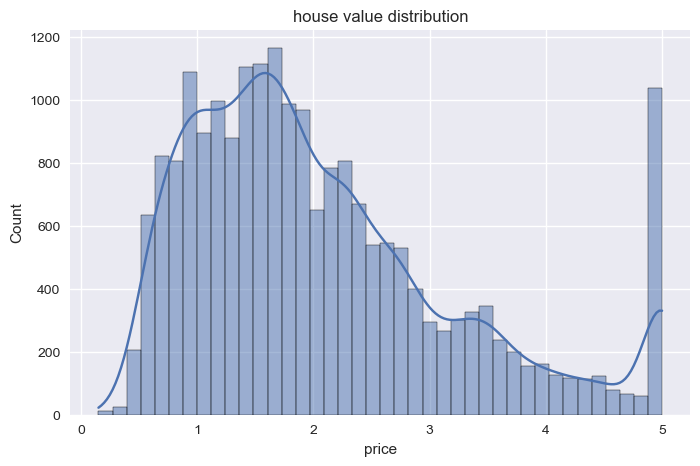

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["MedHouseVal"],
    bins=40,
    kde=True
)

plt.title("house value distribution")
plt.xlabel("price")
plt.show()

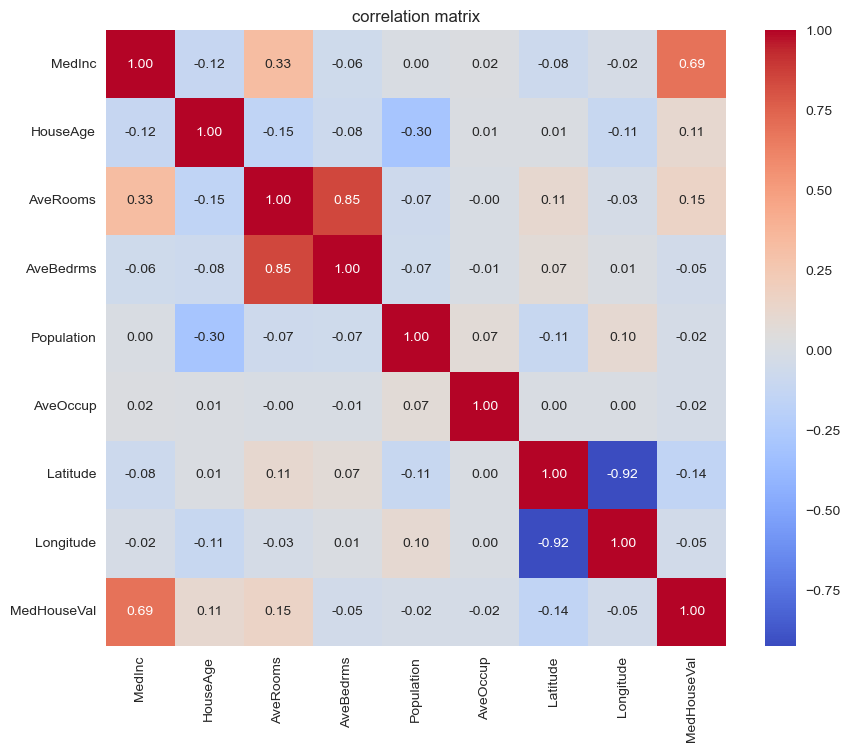

In [18]:
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("correlation matrix")
plt.show()

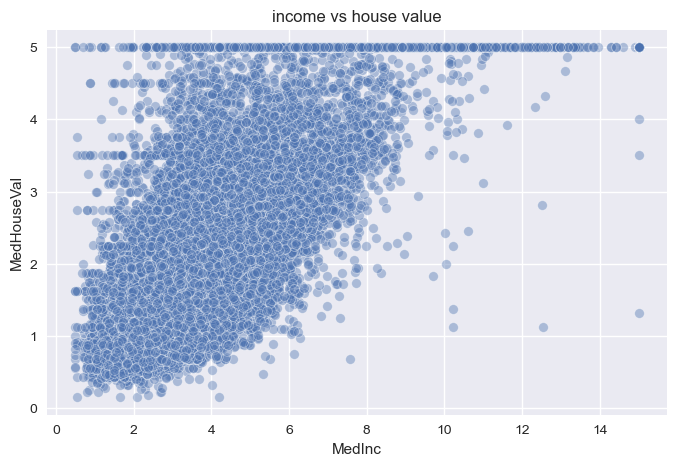

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="MedInc",
    y="MedHouseVal",
    alpha=0.4
)

plt.title("income vs house value")
plt.show()

## train test split

split data into training and testing sets.

In [20]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

(16512, 8)


## ridge regression

find best alpha using cross validation.

In [21]:
alphas = np.logspace(-3,3,100)
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

grid_ridge = GridSearchCV(
    ridge,
    {"ridge__alpha": alphas},
    cv=5,
    scoring="neg_root_mean_squared_error"
)

grid_ridge.fit(X_train,y_train)
ridge_pred = grid_ridge.predict(X_test)
ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_pred
    )
)

print("best alpha:",grid_ridge.best_params_)
print("rmse:",ridge_rmse)

best alpha: {'ridge__alpha': np.float64(0.001)}
rmse: 0.7455813582936551


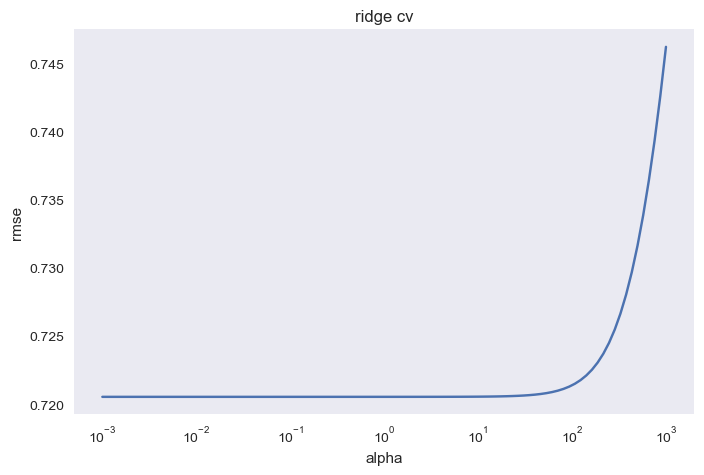

In [22]:
scores = -grid_ridge.cv_results_[
    "mean_test_score"
]

plt.figure(figsize=(8,5))
plt.semilogx(
    alphas,
    scores
)

plt.xlabel("alpha")
plt.ylabel("rmse")
plt.title("ridge cv")
plt.grid()
plt.show()

## lasso regression

perform feature selection and regularization.

In [23]:
lasso = Pipeline([
    ("scaler",StandardScaler()),
    ("lasso",LassoCV(
        cv=5,
        max_iter=10000
    ))
])

lasso.fit(X_train,y_train)
lasso_pred = lasso.predict(X_test)
lasso_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lasso_pred
    )
)

print("rmse:",lasso_rmse)

rmse: 0.7448236405829517


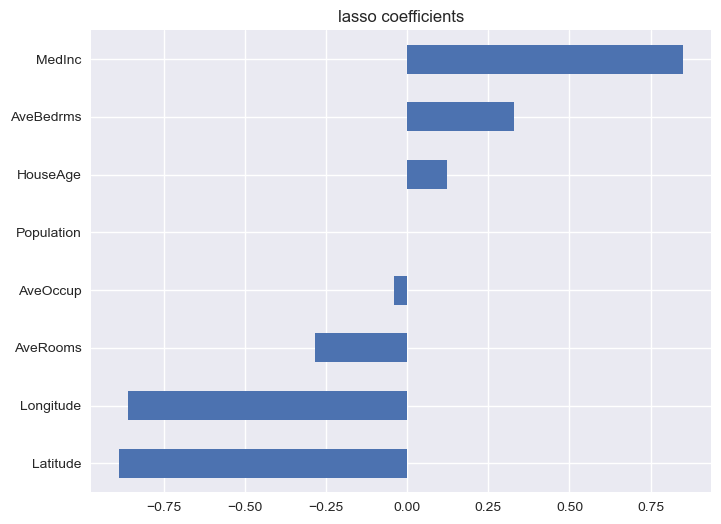

In [24]:
coef = pd.Series(
    lasso.named_steps["lasso"].coef_,
    index=X.columns
)

coef.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("lasso coefficients")
plt.show()

## principal component regression

reduce dimensions using pca.

In [25]:
pcr = Pipeline([
    ("scaler",StandardScaler()),
    ("pca",PCA()),
    ("reg",LinearRegression())
])

param_grid = {
    "pca__n_components":
    range(1,X.shape[1]+1)
}

grid_pcr = GridSearchCV(
    pcr,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

grid_pcr.fit(
    X_train,
    y_train
)

print(
    "best components:",
    grid_pcr.best_params_
)

best components: {'pca__n_components': 8}


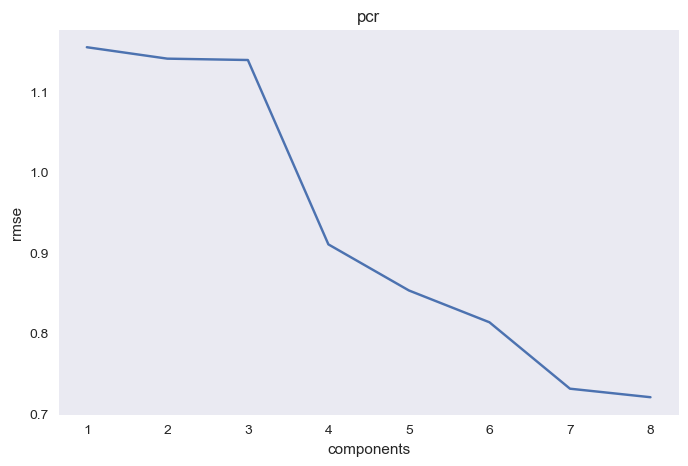

In [26]:
components = range(
    1,
    X.shape[1]+1
)

scores = -grid_pcr.cv_results_[
    "mean_test_score"
]

plt.figure(figsize=(8,5))
plt.plot(
    components,
    scores
)

plt.xlabel("components")
plt.ylabel("rmse")
plt.title("pcr")
plt.grid()
plt.show()

## partial least squares

compare latent components.

In [27]:
rmse_scores = []
for i in range(1,9):

    pls = PLSRegression(
        n_components=i
    )

    scores = cross_val_score(
        pls,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )

    rmse_scores.append(
        -scores.mean()
    )

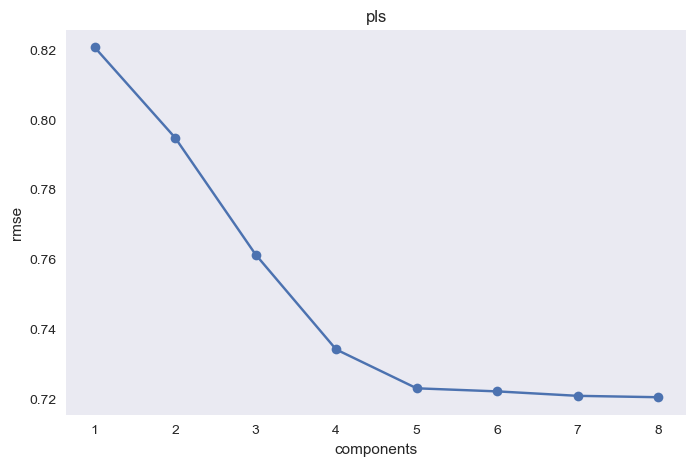

In [28]:
plt.figure(figsize=(8,5))
plt.plot(
    range(1,9),
    rmse_scores,
    marker="o"
)

plt.xlabel("components")
plt.ylabel("rmse")
plt.title("pls")
plt.grid()
plt.show()

In [29]:
results = pd.DataFrame({

    "model":[
        "ridge",
        "lasso",
        "pcr",
        "pls"
    ],

    "rmse":[
        ridge_rmse,
        lasso_rmse,
        min(-grid_pcr.cv_results_[
            "mean_test_score"
        ]),
        min(rmse_scores)
    ]
})

results = results.sort_values(
    "rmse"
)

print(results)

   model      rmse
3    pls  0.720527
2    pcr  0.720527
1  lasso  0.744824
0  ridge  0.745581


## model comparison

compare model performance using rmse.

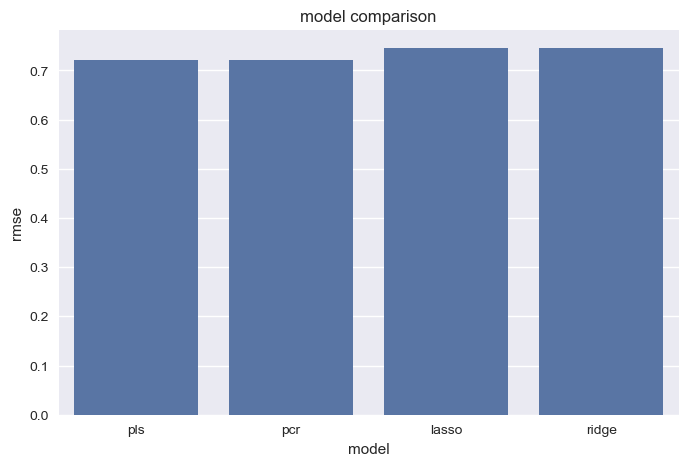

In [30]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=results,
    x="model",
    y="rmse"
)

plt.title(
    "model comparison"
)

plt.show()

In [32]:
# final summary


best_model = results.iloc[0]
print("\nproject summary\n")
print(f"samples: {X.shape[0]}")
print(f"features: {X.shape[1]}\n")
print("models used:")
print("- ridge")
print("- lasso")
print("- pcr")
print("- pls\n")
print("model comparison:")
print(results.round(4))
print("\nbest model:")
print(
    best_model["model"],
    "with rmse =",
    round(best_model["rmse"],4)
)

print("\nselected features by lasso:")

coef = pd.Series(
    lasso.named_steps["lasso"].coef_,
    index=X.columns
)

selected = coef[coef != 0]
print(selected.sort_values(
    ascending=False
))

print("\nproject finished")


project summary

samples: 20640
features: 8

models used:
- ridge
- lasso
- pcr
- pls

model comparison:
   model    rmse
3    pls  0.7205
2    pcr  0.7205
1  lasso  0.7448
0  ridge  0.7456

best model:
pls with rmse = 0.7205

selected features by lasso:
MedInc        0.850206
AveBedrms     0.328723
HouseAge      0.123187
Population   -0.001312
AveOccup     -0.040079
AveRooms     -0.283936
Longitude    -0.860441
Latitude     -0.888039
dtype: float64

project finished


## conclusion

final results and best model.

In [33]:
# conclusion


print("\nconclusion\n")
print(
    "different regularization and "
    "dimension reduction methods "
    "were compared on california housing dataset."
)

print(
    "lasso reduced the number of features "
    "while ridge improved stability."
)

print(
    "pcr and pls reduced dimensionality "
    "and produced competitive results."
)

print(
    f"best model: {best_model['model']}"
)

print(
    f"rmse: {round(best_model['rmse'],4)}"
)


conclusion

different regularization and dimension reduction methods were compared on california housing dataset.
lasso reduced the number of features while ridge improved stability.
pcr and pls reduced dimensionality and produced competitive results.
best model: pls
rmse: 0.7205


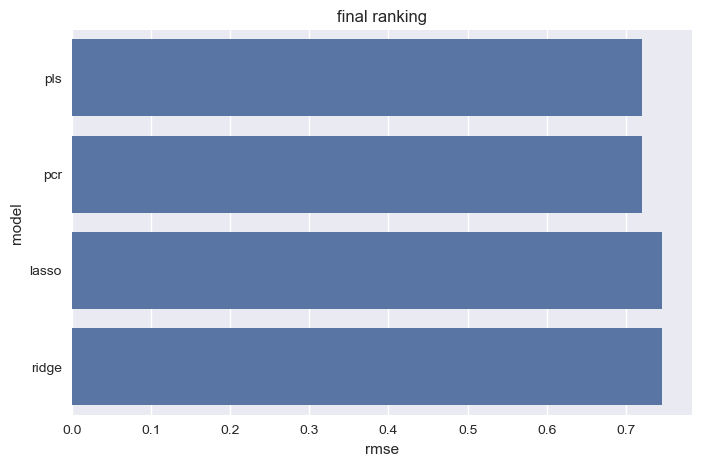

In [34]:
# final ranking


plt.figure(figsize=(8,5))
sns.barplot(
    data=results.sort_values("rmse"),
    x="rmse",
    y="model"
)

plt.title("final ranking")
plt.xlabel("rmse")
plt.ylabel("model")
plt.show()

## libraries

- numpy
- pandas
- matplotlib
- seaborn
- scikit-learn

dataset:
- california housing dataset

evaluation:
- cross validation
- rmse

author:
amirmahdimanaseir